# [LAB 06] 데이터 시각화 - 13. Convex Hull

## #01. 준비작업 

In [1]:
!pip install --upgrade scipy


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 2. 패키지 참조 

In [2]:
from jussam import load_data
from helpers import *
import seaborn as sb
import numpy as np
from scipy.spatial import ConvexHull

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 3. 데이터 셋 가져오기 

In [3]:
origin = load_data("iris")
origin.head()

📚 1936년 영국의 통계학자 로널드 피셔(Ronald A. Fisher)가 소개한 3가지 품종(setosa, versicolor, virginica)의 붓꽃(Iris)에 대한 꽃받침과 꽃잎의 길이와 너비 측정값으로 구성된 유명한 머신러닝 및 데이터 분석용 데이터셋.(출처: Kaggle)

    field         description
--  ------------  -------------
 0  Sepal.Length  꽃받침 길이
 1  Sepal.Width   꽃받침 너비
 2  Petal.Length  꽃잎 길이
 3  Petal.Width   꽃잎 너비
 4  Species       품종



,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.100,3.500,1.400,0.200,setosa
1,4.900,3.000,1.400,0.200,setosa
2,4.700,3.200,1.300,0.200,setosa
3,4.600,3.100,1.500,0.200,setosa
4,5.000,3.600,1.400,0.200,setosa


## #02. 기본 사용 방법 

### 1. iris 데이터의 종류별 분포 확인 

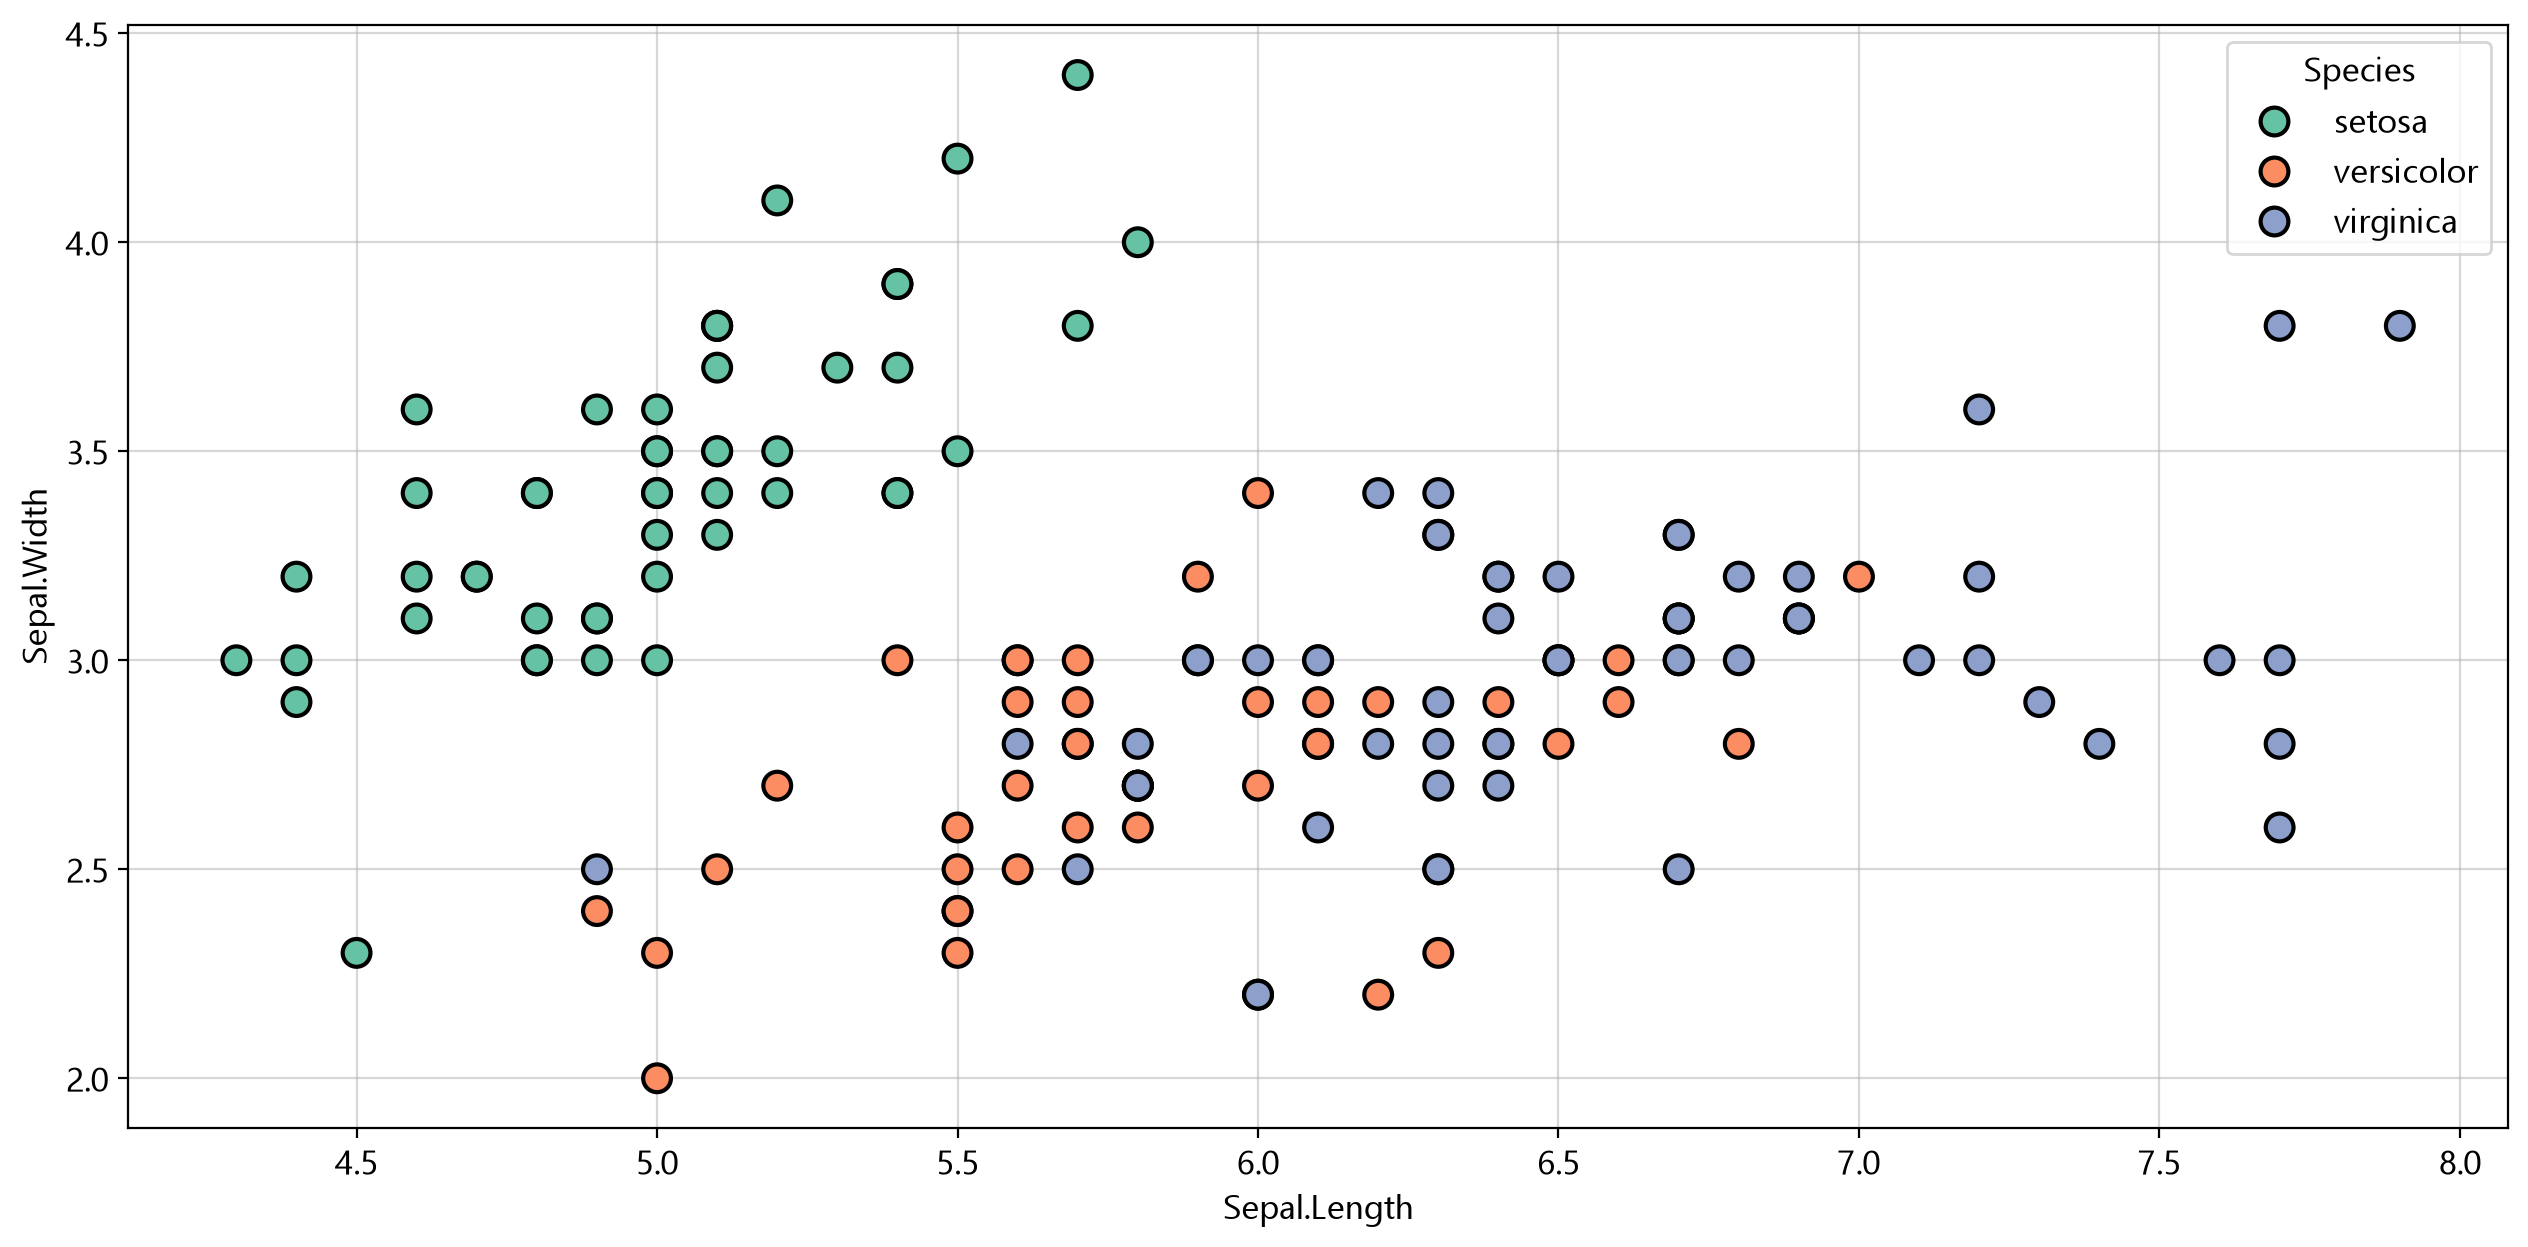

In [4]:
my_plot.init()

# 산점도 시각화 
sb.scatterplot(data=origin, 
               x='Sepal.Length', y='Sepal.Width', hue='Species', 
               s=100, edgecolor="#000000", linewidth=1.5,
               palette='Set2')
my_plot.show()

### 2. ConvexHull 알고리즘 적용을 위해 한 가지 종류(setosa)의 데이터만 분리

In [5]:
df_c = origin.loc[origin['Species'] == 'setosa',
                  ['Sepal.Length', 'Sepal.Width']]

# ConvexHull은 3개 이상의 점이 필요하므로, 
# 데이터 포인트가 3개 미만인 경우 중단해야 함 
if len(df_c) < 3: 
    print("데이터 포인트가 3개 미만이므로 ConvexHull을 그릴 수 없습니다.")

df_c.head()

,Sepal.Length,Sepal.Width
0,5.100,3.500
1,4.900,3.000
2,4.700,3.200
3,4.600,3.100
4,5.000,3.600


### 3. setosa종 데이터에 대한 가장 외곽 포인터의 인덱스 구하기 

In [6]:
hull = ConvexHull(df_c)
out_index = hull.vertices
out_index

array([13, 41, 36, 18, 14, 15, 32, 22], dtype=int32)

### 4. 첫번째 인덱스를 마지막에 추가하기 

In [7]:
points = np.append(out_index, out_index[0])
points

array([13, 41, 36, 18, 14, 15, 32, 22, 13], dtype=int32)

### 5. 산점도 그래프와 함께 표현하기 

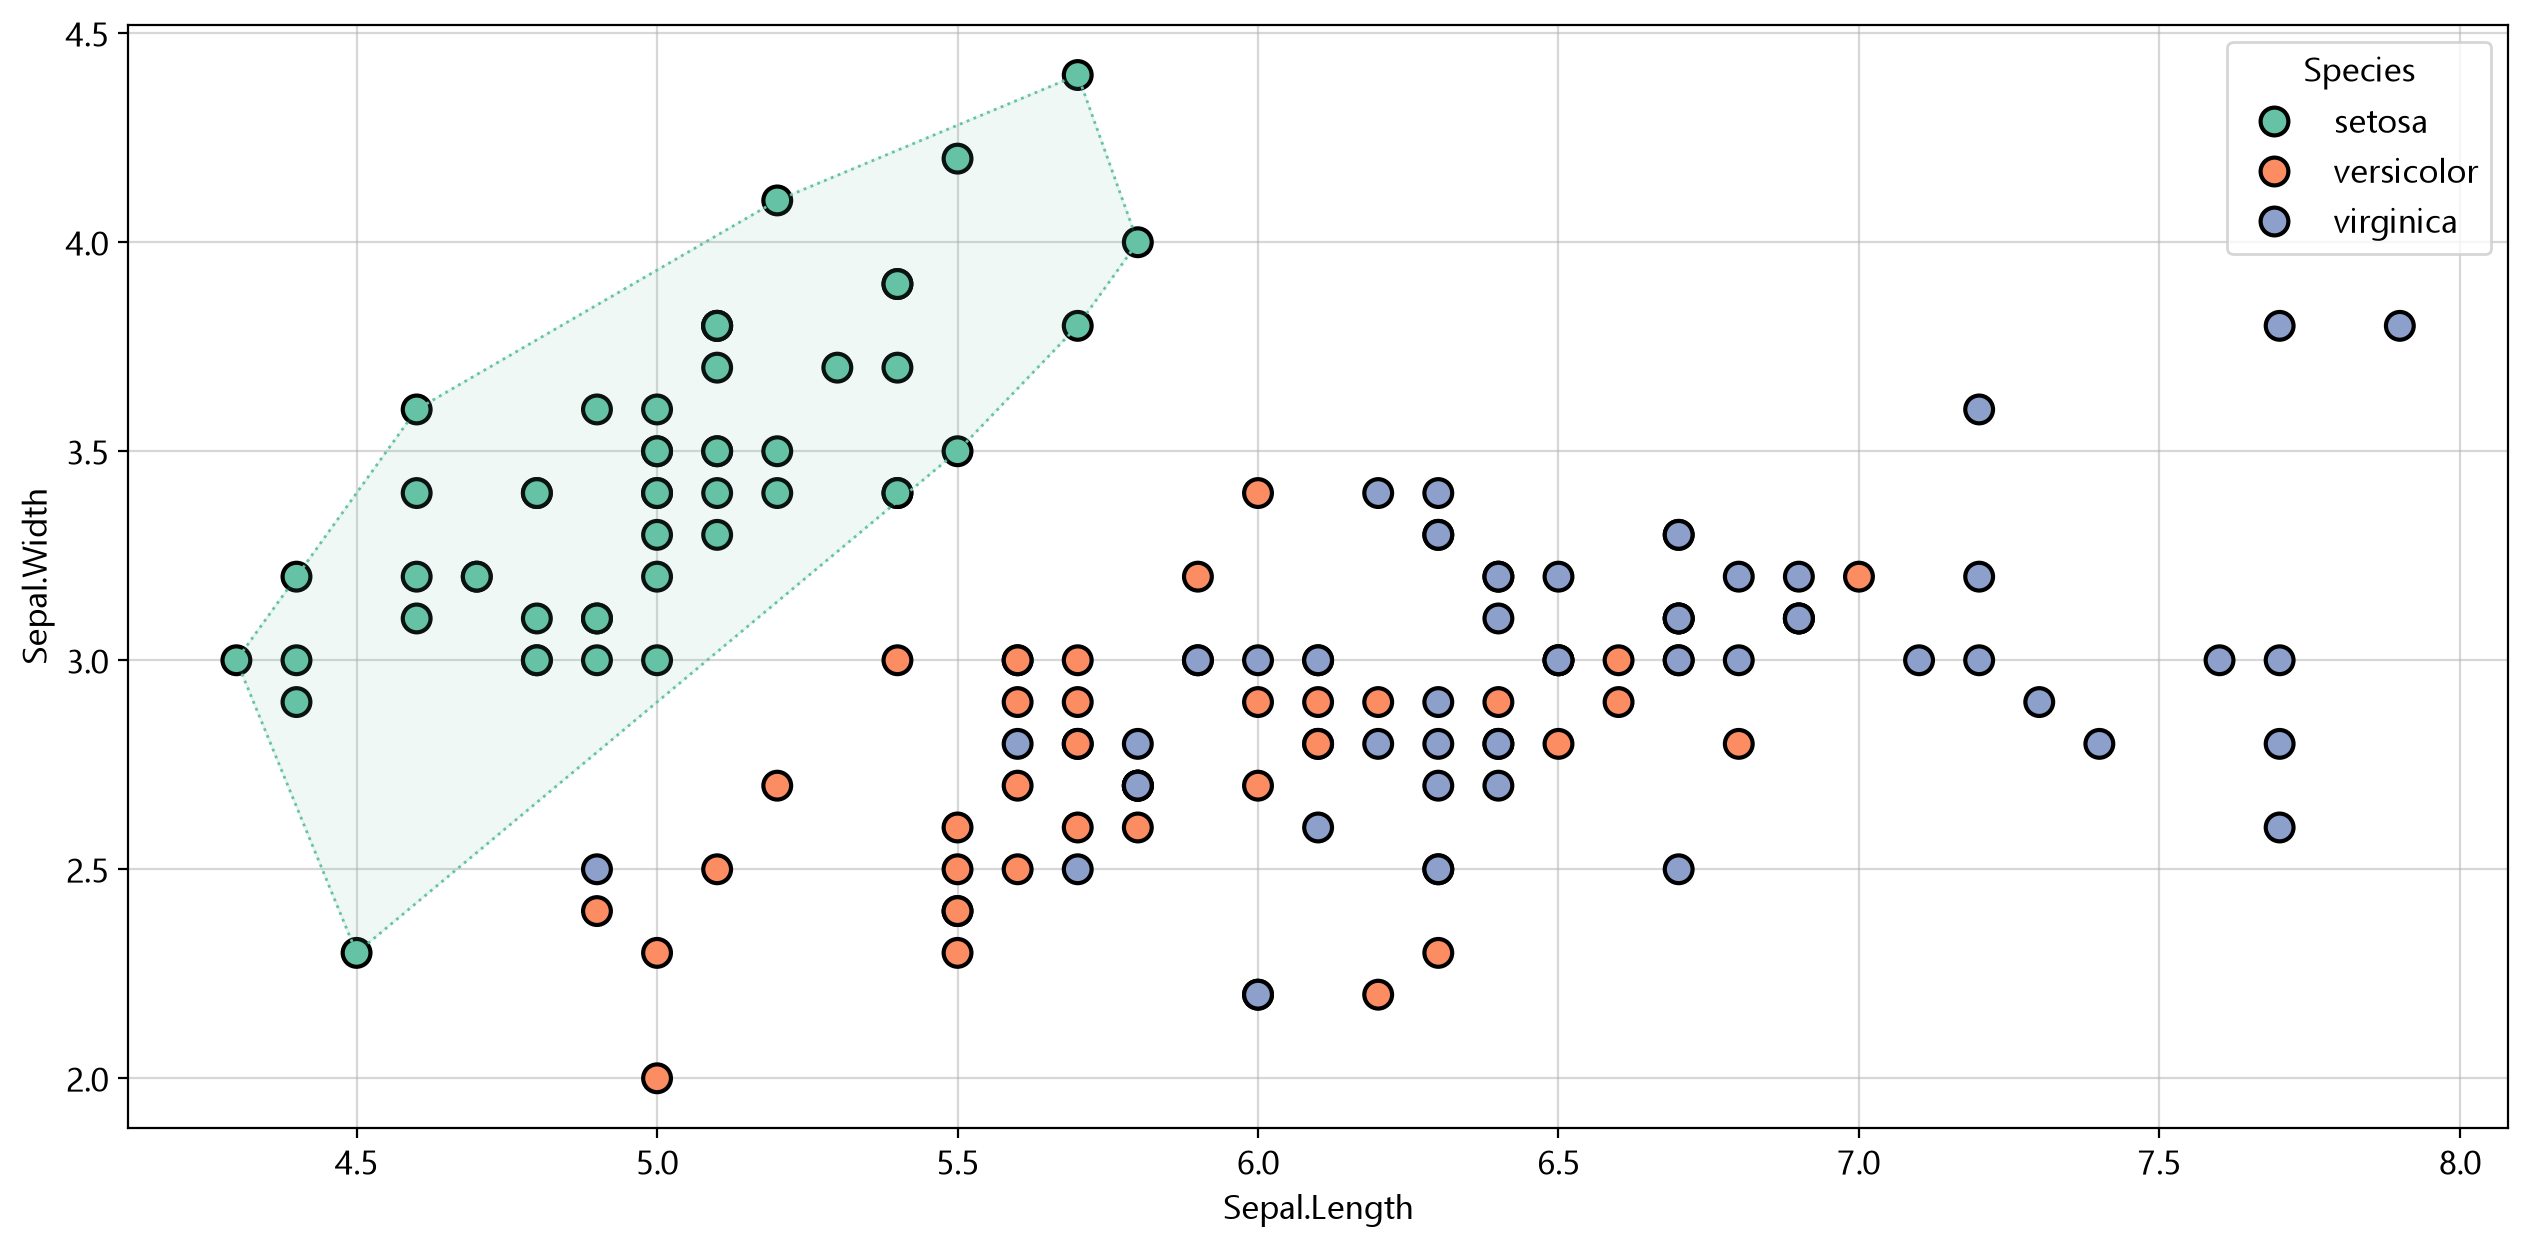

In [8]:
fig, ax = my_plot.init()

# 산점도 시각화 
sb.scatterplot(data=origin,
               x='Sepal.Length', y='Sepal.Width', hue='Species',
               s=100, edgecolor="#000000", linewidth=1.5,
               palette='Set2'
)

# 색상값 생성 
color = sb.color_palette('Set2')[0]

# points를 index로 하는 데이터 포인트를 선으로 표시
ax.plot(df_c.iloc[points, 0], df_c.iloc[points, 1], linewidth=1,
        linestyle=":", color=color)

# points를 index로 하는 데이터 포인트를 면으로 채우기 
ax.fill(df_c.iloc[points, 0], df_c.iloc[points, 1], alpha=0.1, color=color)

my_plot.show()

## #03. 모든 군집에 일괄 적용 

### 1. 외곽선 처리 함수 정의 

In [9]:
def plot_hull(data, x, y, hue, palette, ax):
    # 데이터의 군집 종류 얻기 
    classes = list(data[hue].unique())

    # 각 클래스에 대하여 반복 수행 
    for i, v in enumerate(classes):
        # 현재 클래스에 해당하는 데이터 포인트 추출
        df_c = data.loc[data[hue] == v, [x, y]]

        # ConvexHull은 3개 이상의 점이 필요하므로, 데이터 포인트가 3개 미만인 경우 중단해야 함 
        if len(df_c) < 3: 
            continue 

        hull = ConvexHull(df_c)
        points = np.append(hull.vertices, hull.vertices[0])

        # 현재 클래스에 적용될 색상값 생성 
        color = sb.color_palette(palette)[i]

        # points를 index로 하는 데이터 포인트를 선과 면으로 표시 
        ax.plot(df_c.iloc[points, 0],df_c.iloc[points,1], linewidth=1, linestyle=":",color= color)
        ax.plot(df_c.iloc[points, 0],df_c.iloc[points,1], alpha=0.1 ,color= color)
                

### 2. 산점도 그래프에 외곽선 적용 

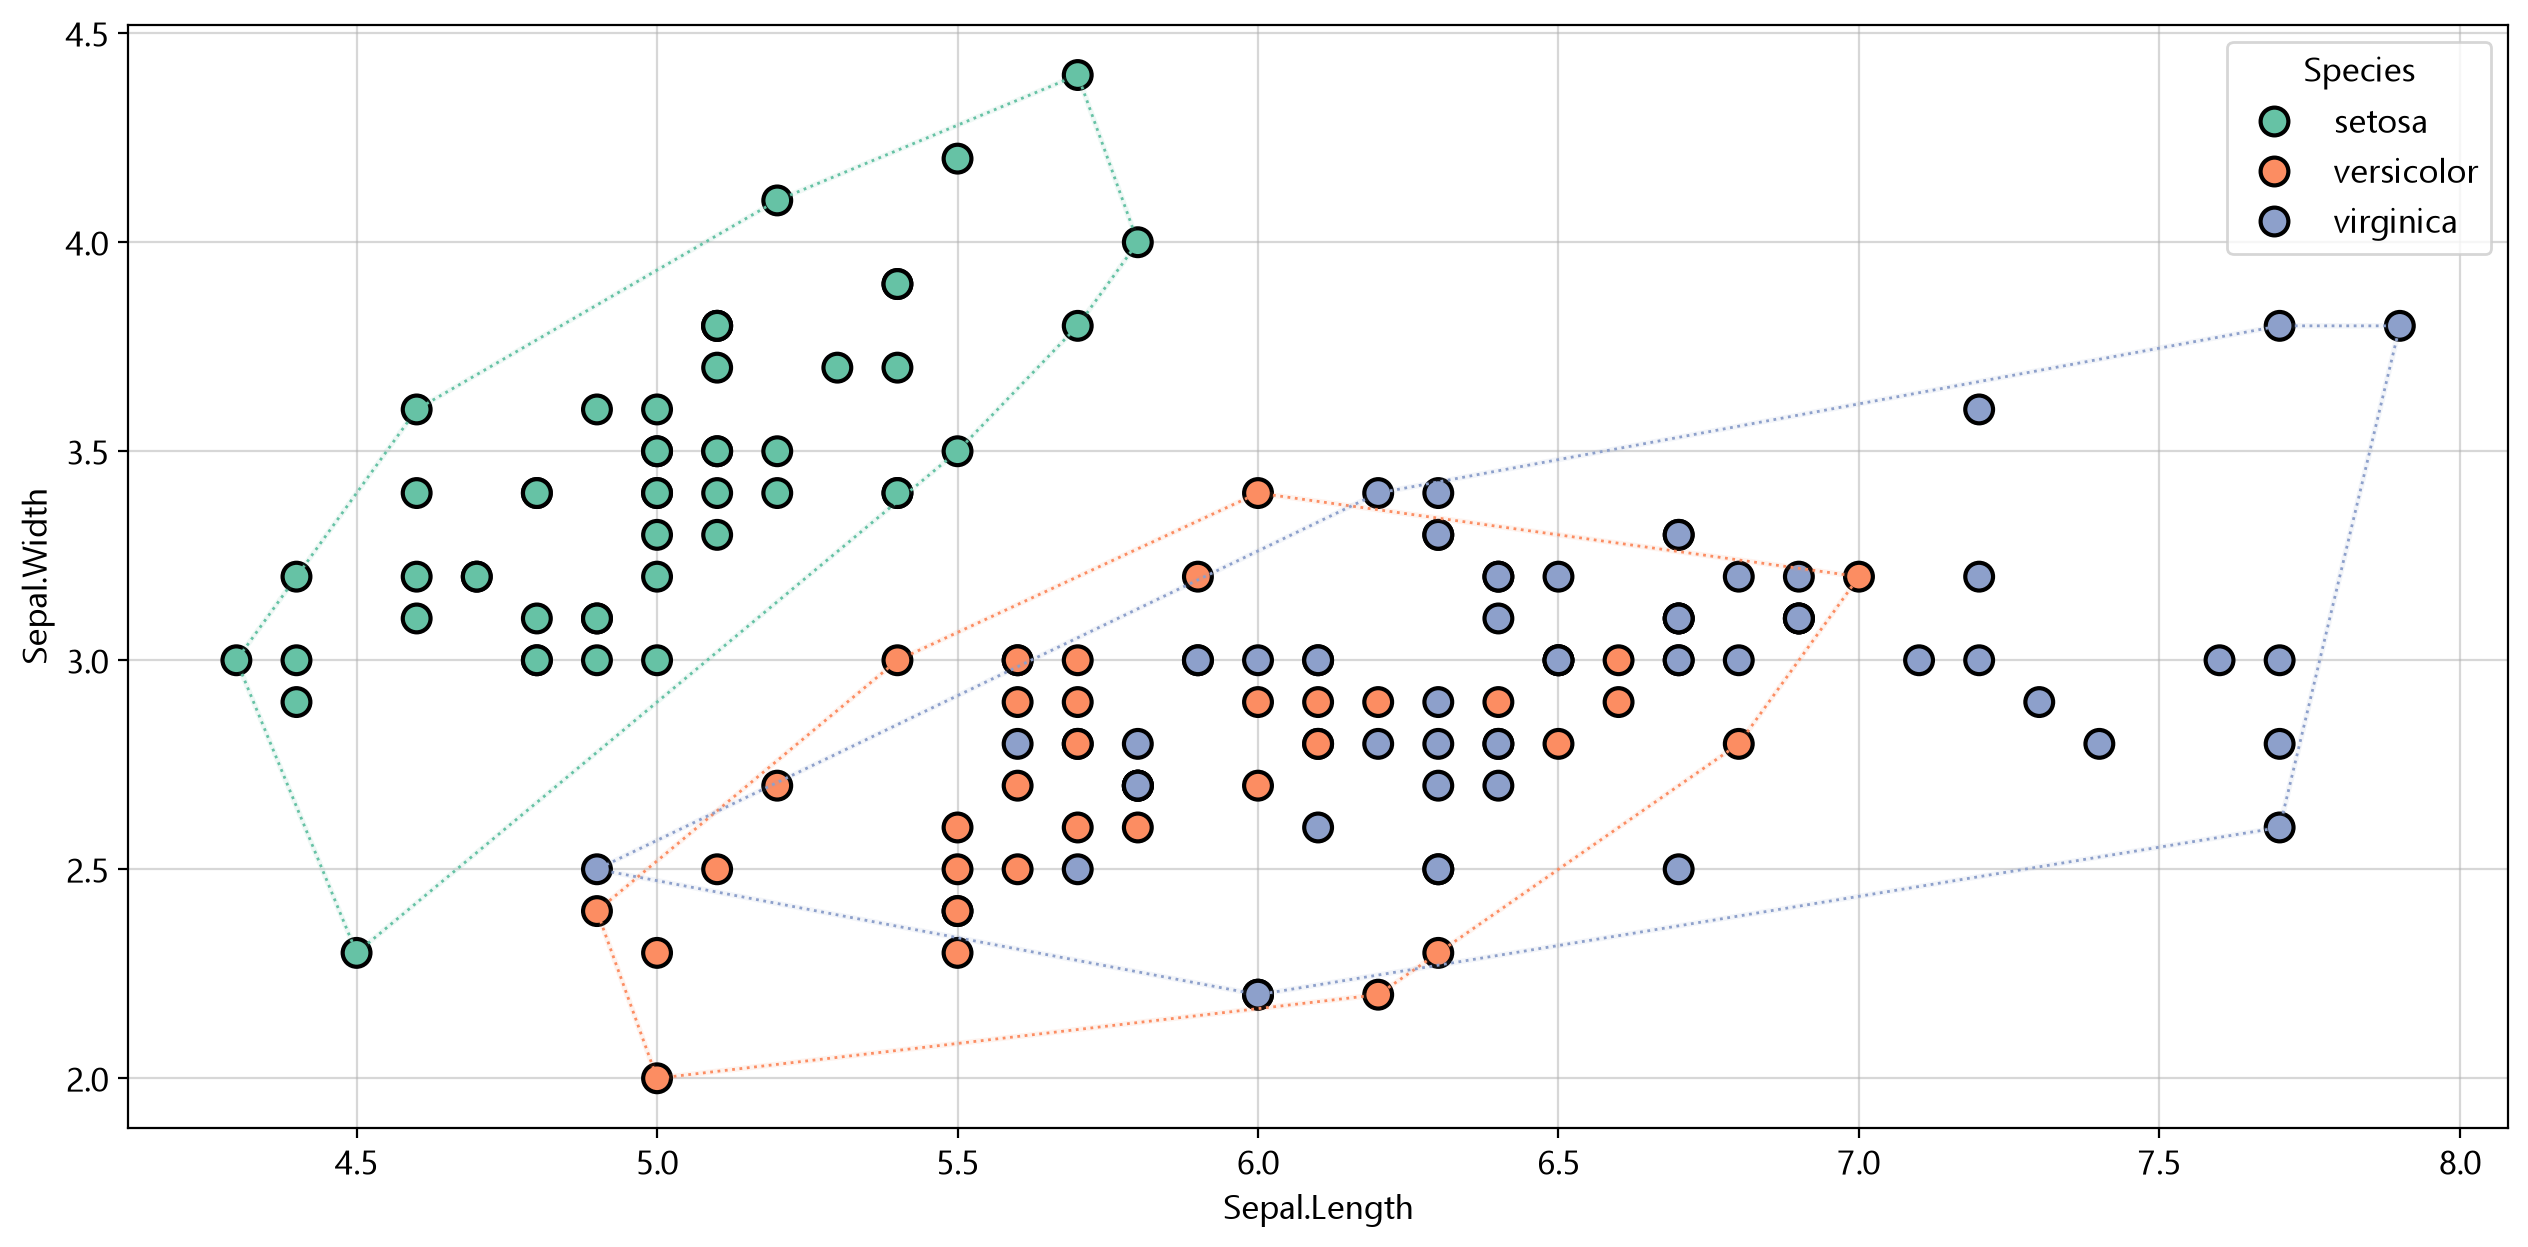

In [10]:
fig, ax = my_plot.init()

# 산점도 시각화 
sb.scatterplot(data=origin, x='Sepal.Length', y='Sepal.Width', hue='Species',
               s=100, edgecolor="#000000", linewidth=1.5, palette='Set2')

# 정의한 함수 호출 
plot_hull(origin, x='Sepal.Length', y='Sepal.Width', hue='Species', 
          palette='Set2', ax=ax)

my_plot.show()

## #05. 모듈화 기능 확인 

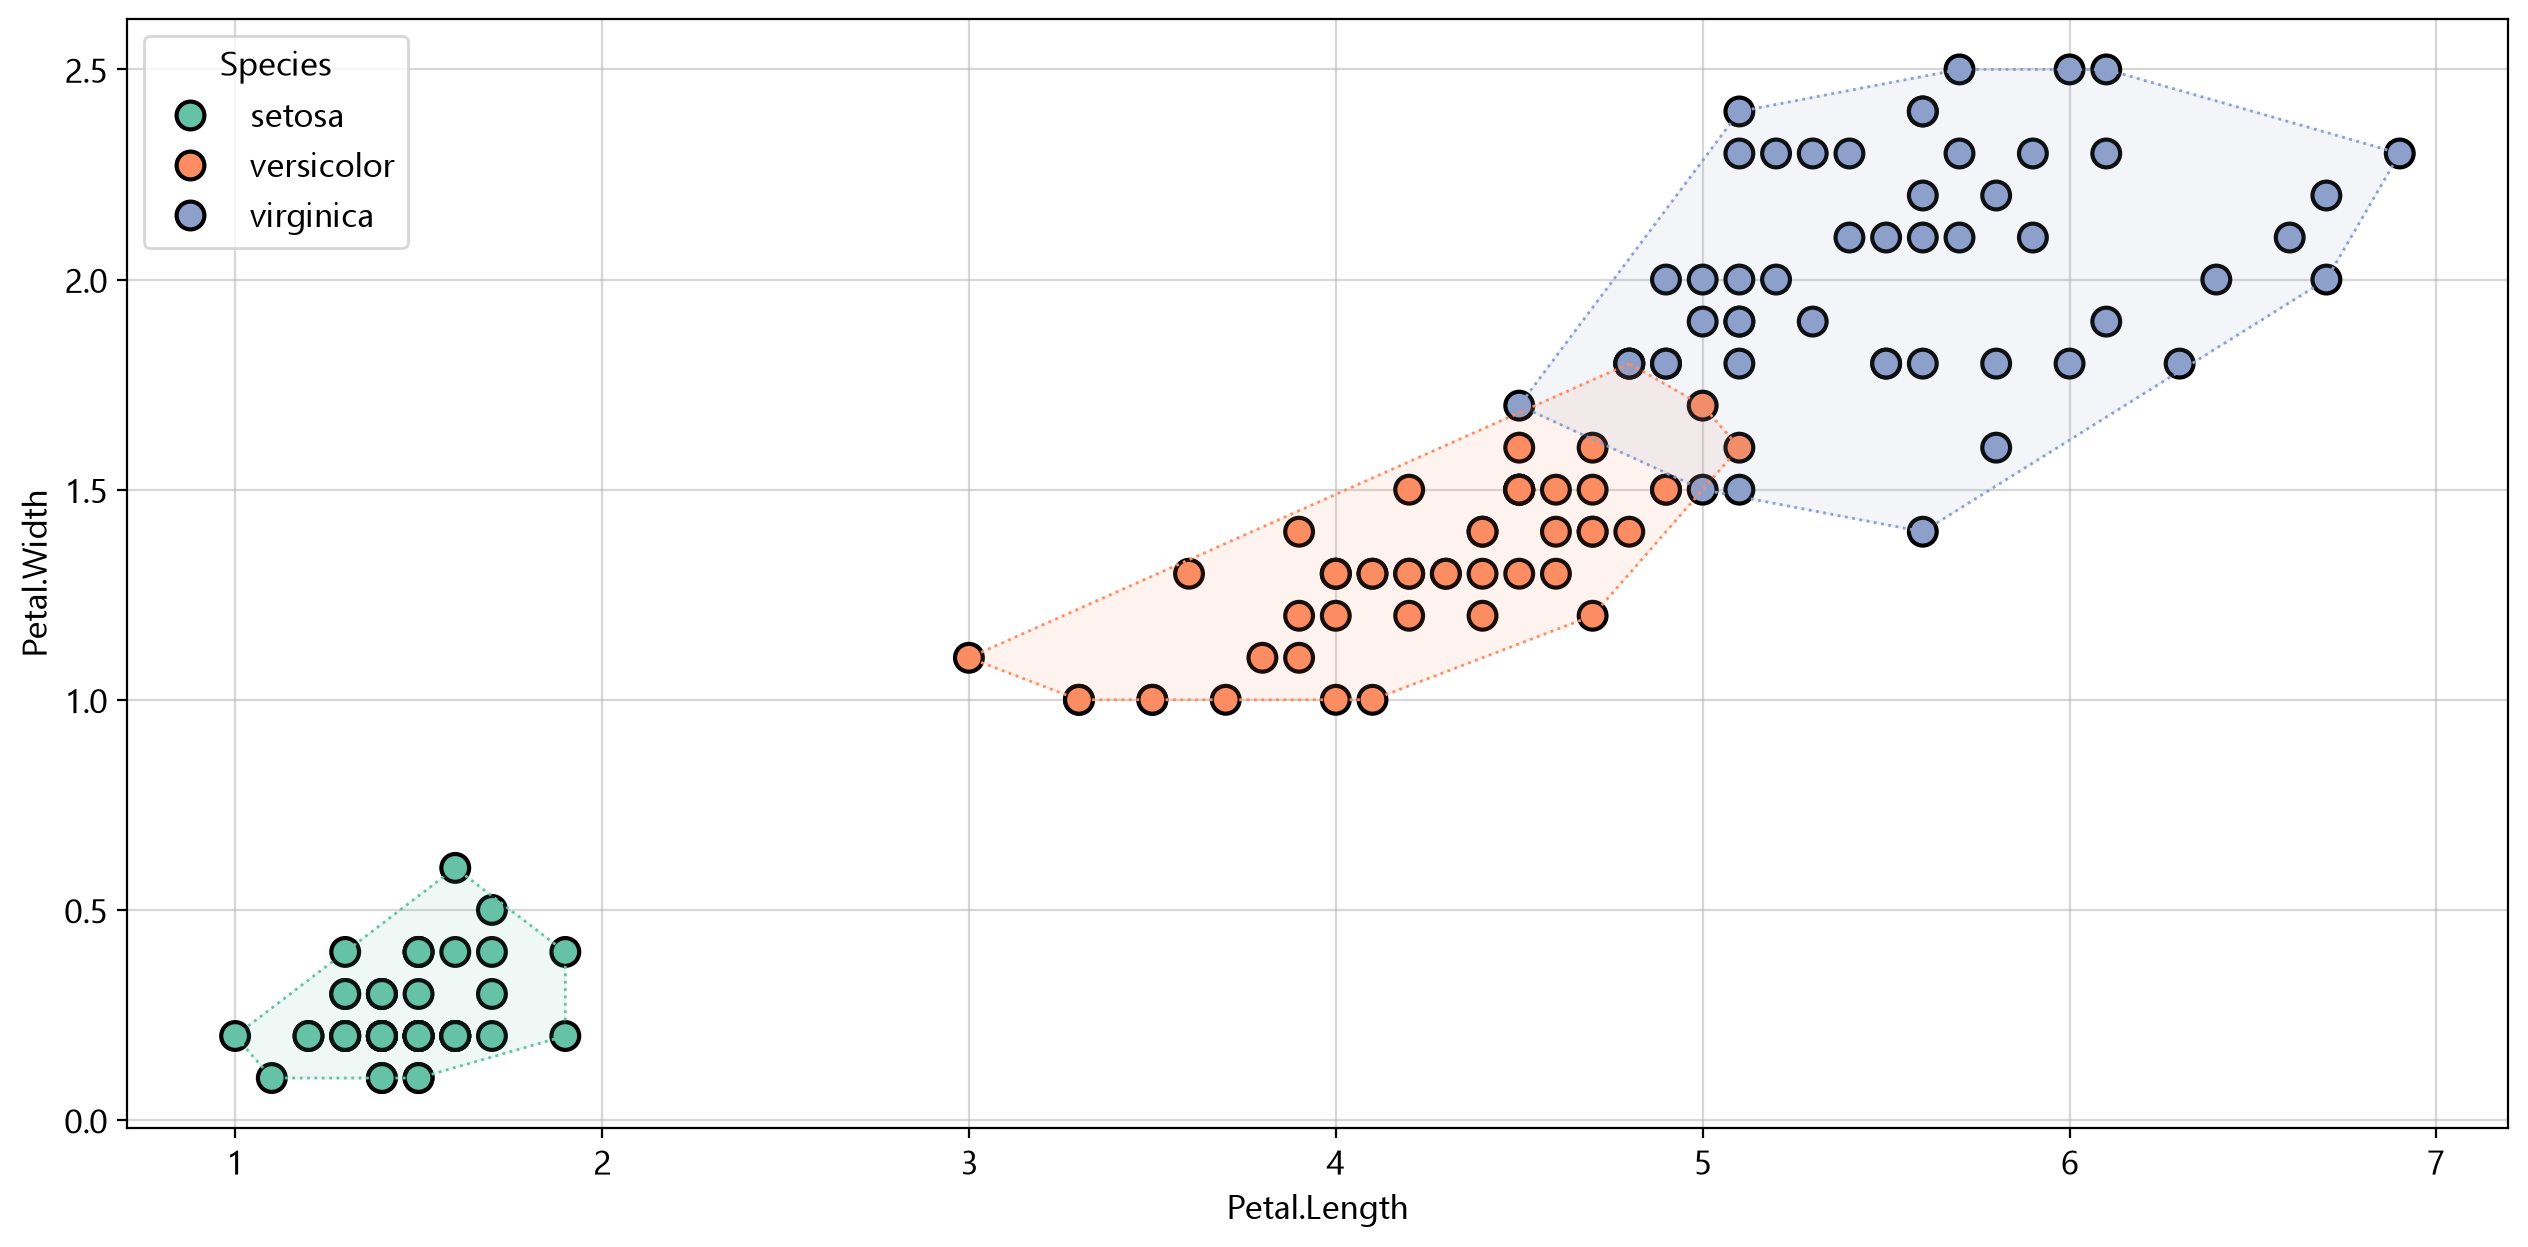

In [11]:
my_plot.scatterplot(data=origin, 
                    x='Petal.Length', y='Petal.Width', hue='Species',
                    size=100, edgecolor="#000000", linewidth=1.5, palette='Set2',
                    outline=True
                    )

## #01. 연습문제 - 별빛시의 영토 지도 그리기 

In [15]:
from jussam import load_data
from helpers import my_plot
import seaborn as sb
import numpy as np

In [16]:
# 시설 분포 산점도 위에 각 구역의 영역 경계선 

In [17]:
origin = load_data('byeolbit_city')
origin.head()

📚 가상의 신도시 별빛시(Byeolbit City) 의 도시계획 데이터


,시설ID,시설명,구역,X좌표,Y좌표,일평균방문객
0,1001,상가01,상업지구,6.270,8.830,923
1,1002,상가02,상업지구,5.060,7.900,929
2,1003,상가03,상업지구,6.680,8.760,1442
3,1004,상가04,상업지구,6.850,7.830,678
4,1005,상가05,상업지구,4.240,9.110,646


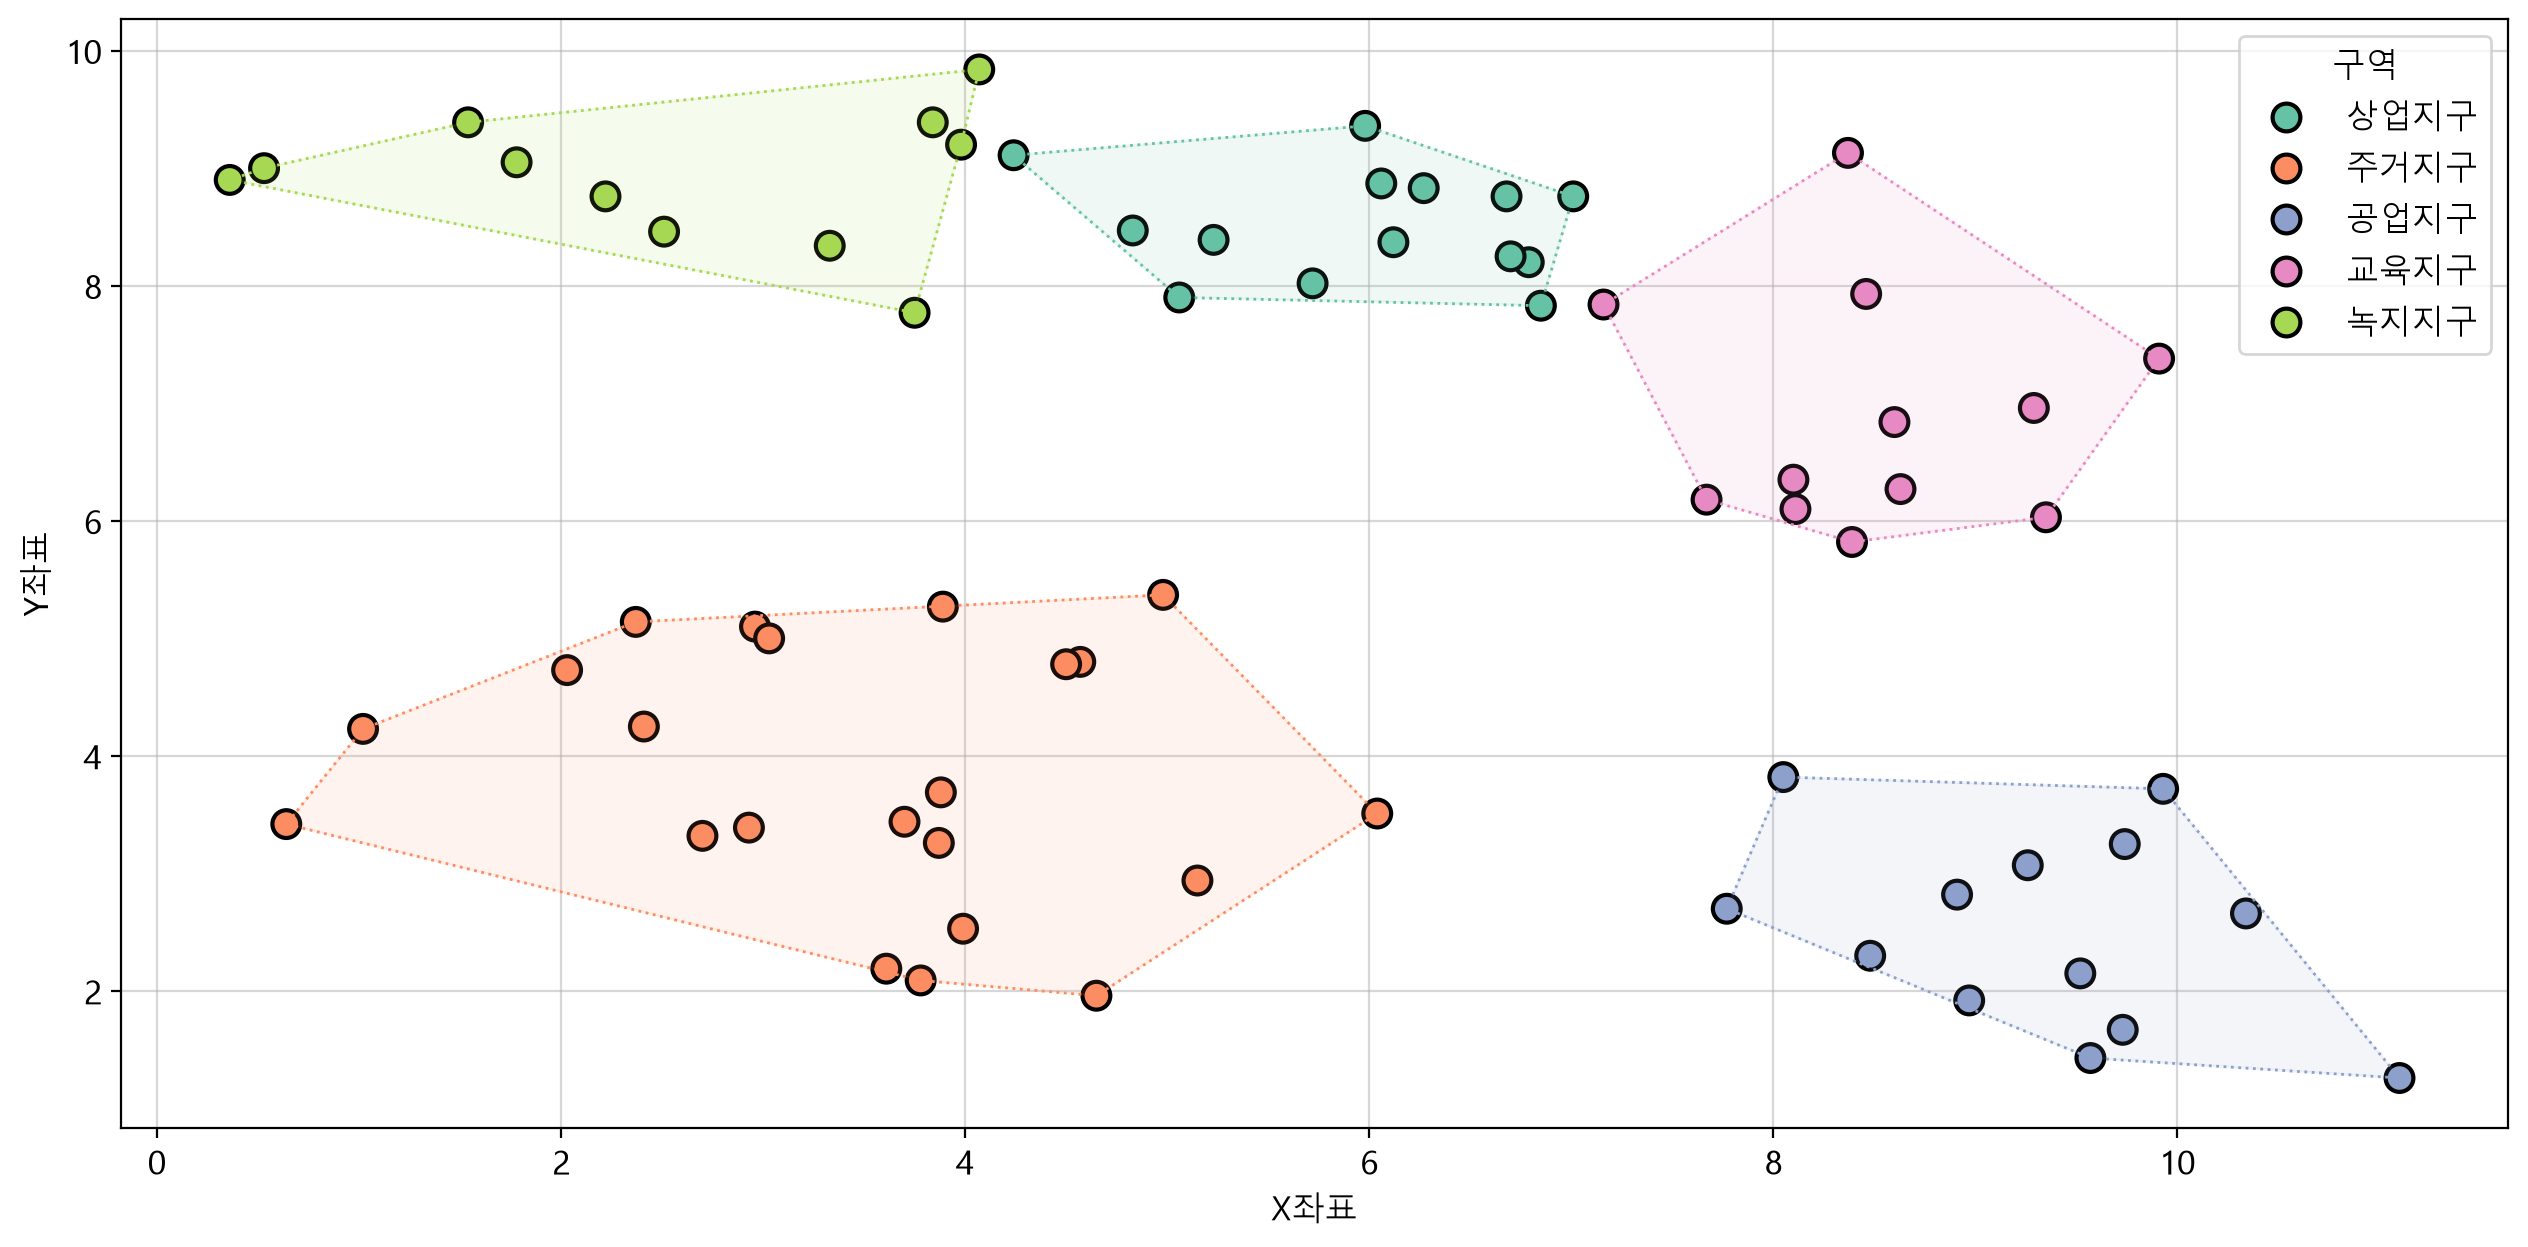

In [18]:
my_plot.scatterplot(data=origin, 
                    x='X좌표', y='Y좌표', hue='구역',
                    size=100, edgecolor="#000000", linewidth=1.5, palette='Set2',
                    outline=True
                    )